In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col, round, lit, count, stddev, when

# PySpark plugin for MongoDB
spark = SparkSession.builder \
    .appName("PISA-Finland-Analysis") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.4.0") \
    .getOrCreate()

uri_2022 = "mongodb://127.0.0.1:27017/pisa_database.year2022"
df_2022 = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri_2022).load()

In [2]:
def get_finland_stats(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    fin_df = df.filter(col("CNT") == "FIN")
    
    # Choosing the correct ICT column based on the year
    ict_col_name = "ICTAVHOM_SUM" if "ICTAVHOM_SUM" in df.columns else "ICTAVHOM"
    
    # Averages and rounding directly in Spark
    stats = fin_df.select(
        round(avg("PV1MATH"), 2).alias("avg_math"),
        round(avg(ict_col_name), 2).alias("avg_ict")
    ).collect()[0]
    
    return stats

try:
    print("\n--- PISA ANALYSIS: FINLAND 2012 vs 2022 ---\n")
    
    stats_2012 = get_finland_stats(2012)
    stats_2022 = get_finland_stats(2022)
    
    print(f"Year 2012 (Mathematics): {stats_2012['avg_math']} points")
    print(f"Year 2012 (ICT Availability): {stats_2012['avg_ict']} (WLE index)")
    print("-" * 40)
    print(f"Year 2022 (Mathematics): {stats_2022['avg_math']} points")
    print(f"Year 2022 (ICT Availability): {stats_2022['avg_ict']} (sum variable)")
    
    # Calculating change
    change = stats_2022['avg_math'] - stats_2012['avg_math']
    print(f"\nChange in mathematics proficiency: {change:.2f} points.")

except Exception as e:
    print(f"Error in analysis: {e}")



--- PISA ANALYSIS: FINLAND 2012 vs 2022 ---



Year 2012 (Mathematics): 507.53 points
Year 2012 (ICT Availability): 38.49 (WLE index)
----------------------------------------
Year 2022 (Mathematics): 475.28 points
Year 2022 (ICT Availability): 5.67 (sum variable)

Change in mathematics proficiency: -32.25 points.


In [ ]:
def get_correlation(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    if "ICTAVHOM_SUM" in df.columns:
        ict_col = "ICTAVHOM_SUM"
    elif "ICTAVHOM" in df.columns:
        ict_col = "ICTAVHOM"
    else:
        print(f"Warning: Year {year} data does not contain the ICTAVHOM column.")
        return None

    fin_df = df.filter(
        (col("CNT") == "FIN") & 
        (col(ict_col).isNotNull()) & 
        (col("PV1MATH").isNotNull())
    )
    
    try:
        correlation = fin_df.stat.corr(ict_col, "PV1MATH")
        return correlation
    except Exception as e:
        print(f"Error calculating correlation for year {year}: {e}")
        return None

corr_2012 = get_correlation(2012)
corr_2022 = get_correlation(2022)

print(f"\n--- CORRELATION ANALYSIS (ICT vs. MATHEMATICS) ---")
print(f"Correlation in 2012: {corr_2012:.3f}")
print(f"Correlation in 2022: {corr_2022:.3f}")


--- CORRELATION ANALYSIS (ICT vs. MATHEMATICS) ---
Correlation in 2012: 0.067
Correlation in 2022: 0.117


In [14]:
from pyspark.sql.functions import col, when, avg, round as spark_round, count

def analyze_math_by_full_week(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # 1. Loading data and selecting relevant columns
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("CNT", "PV1MATH", "ICTWKDY", "ICTWKEND")
    
    # 2. Calculating the full week weighted Internet usage (ICT_TOTAL)
    df = df.withColumn("ICT_TOTAL", 
        ((col("ICTWKDY") * 5) + (col("ICTWKEND") * 2)) / 7
    )
    
    # 3. Categorizing students into usage groups based on the year-specific thresholds
    if year == 2012:
        df = df.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") <= 3.5, "1. Low (0-1h)")
            .when((col("ICT_TOTAL") > 3.5) & (col("ICT_TOTAL") <= 5.5), "2. Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 5.5, "3. Heavy (4h+)")
            .otherwise(None))
    else:
        df = df.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") < -0.5, "1. Low (0-1h)")
            .when((col("ICT_TOTAL") >= -0.5) & (col("ICT_TOTAL") <= 1.0), "2. Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 1.0, "3. Heavy (4h+)")
            .otherwise(None))

    # 4. Filtering for Finnish students and calculating average mathematics scores by usage group
    stats = df.filter((col("CNT") == "FIN") & (col("Usage_Group").isNotNull())) \
        .groupBy("Usage_Group") \
        .agg(
            spark_round(avg("PV1MATH"), 1).alias("Avg_Math"),
            count("PV1MATH").alias("N_Students") 
        ).orderBy("Usage_Group")
    
    return stats

# --- EXECUTION ---
try:
    print("\n" + "="*65)
    print("ANALYSIS: MATHEMATICS VS. INTERNET USAGE")
    print("="*65)
    
    for year in [2012, 2022]:
        print(f"\nVuosi {year}:")
        analyze_math_by_full_week(year).show()

except Exception as e:
    print(f"Virhe analyysissä: {e}")


ANALYSIS: MATHEMATICS VS. INTERNET USAGE

Vuosi 2012:
+------------------+--------+----------+
|       Usage_Group|Avg_Math|N_Students|
+------------------+--------+----------+
|     1. Low (0-1h)|   521.3|      1831|
|2. Moderate (1-4h)|   515.8|      4332|
|    3. Heavy (4h+)|   484.6|      2666|
+------------------+--------+----------+


Vuosi 2022:
+------------------+--------+----------+
|       Usage_Group|Avg_Math|N_Students|
+------------------+--------+----------+
|     1. Low (0-1h)|   503.1|      1599|
|2. Moderate (1-4h)|   492.0|      5567|
|    3. Heavy (4h+)|   432.4|       828|
+------------------+--------+----------+



In [12]:
from pyspark.sql.functions import col, stddev

def check_math_correlation_full_week(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # 1. Loading data and selecting relevant columns
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("CNT", "PV1MATH", "ICTWKDY", "ICTWKEND")
    
    # 2. Calculating the full week weighted Internet usage (ICT_TOTAL)
    df_combined = df.withColumn("ICT_TOTAL", 
        ((col("ICTWKDY") * 5) + (col("ICTWKEND") * 2)) / 7
    )
    
    # 3. Filtering: Finland and ensuring no null values in the columns used for calculation
    fin_df = df_combined.filter(
        (col("CNT") == "FIN") & 
        (col("ICT_TOTAL").isNotNull()) & 
        (col("PV1MATH").isNotNull())
    )
    
    # 4. Calculating correlation between the new ICT_TOTAL variable and mathematics
    r = fin_df.stat.corr("ICT_TOTAL", "PV1MATH")
    
    # 5. Calculating the standard deviation of mathematics scores
    std_dev = fin_df.select(stddev("PV1MATH")).collect()[0][0]
    
    return r, std_dev

# --- EXECUTION AND COMPARISON ---
try:
    r12, sd12 = check_math_correlation_full_week(2012)
    r22, sd22 = check_math_correlation_full_week(2022)
    
    print("\n" + "="*60)
    print("CORRELATION: TOTAL WEEKLY INTERNET USAGE VS. MATHEMATICS")
    print("="*60)
    print(f"Year 2012: r = {r12:.3f} (Standard Deviation: {sd12:.1f})")
    print(f"Year 2022: r = {r22:.3f} (Standard Deviation: {sd22:.1f})")
    
    # Korrelaation prosentuaalinen muutos
    change = ((r22 - r12) / abs(r12)) * 100
    print(f"\nAnalysis: The correlation coefficient has changed by {change:.1f} %")
    print("="*60)

except Exception as e:
    print(f"Error in correlation analysis: {e}")


CORRELATION: TOTAL WEEKLY INTERNET USAGE VS. MATHEMATICS
Year 2012: r = -0.250 (Standard Deviation: 89.9)
Year 2022: r = -0.208 (Standard Deviation: 89.7)

Analysis: The correlation coefficient has changed by 16.8 %


In [17]:
from pyspark.sql.functions import col, when, round as spark_round, stddev

def check_math_correlation_with_full_week(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # Loading data and selecting relevant columns
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("CNT", "PV1MATH", "ICTWKDY", "ICTWKEND")
    
    # Calculating the full week weighted Internet usage (ICT_TOTAL)
    df_combined = df.withColumn("ICT_TOTAL", 
        ((col("ICTWKDY") * 5) + (col("ICTWKEND") * 2)) / 7
    )
    
    # Grouping students into usage groups based on the year-specific thresholds
    if year == 2012:
        df_grouped = df_combined.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") <= 3.5, "Low (0-1h)")
            .when((col("ICT_TOTAL") > 3.5) & (col("ICT_TOTAL") <= 5.5), "Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 5.5, "Heavy (4h+)")
            .otherwise(None))
    else:
        df_grouped = df_combined.withColumn("Usage_Group", 
            when(col("ICT_TOTAL") < -0.5, "Low (0-1h)")
            .when((col("ICT_TOTAL") >= -0.5) & (col("ICT_TOTAL") <= 1.0), "Moderate (1-4h)")
            .when(col("ICT_TOTAL") > 1.0, "Heavy (4h+)")
            .otherwise(None))

    # Filtering for Finnish students and cleaning
    fin_df = df_grouped.filter(
        (col("CNT") == "FIN") & 
        (col("Usage_Group").isNotNull()) & 
        (col("PV1MATH").isNotNull())
    )
    
    results = {}
    for g in ["Low (0-1h)", "Moderate (1-4h)", "Heavy (4h+)"]:
        group_df = fin_df.filter(col("Usage_Group") == g)
        if group_df.count() > 1:
            r = group_df.stat.corr("ICT_TOTAL", "PV1MATH")
            sd = group_df.select(stddev("PV1MATH")).collect()[0][0]
            count = group_df.count()
            results[g] = (r, sd, count)
            
    return results

# --- EXECUTION ---
try:
    print("\n" + "="*60)
    print("TOTAL WEEKLY INTERNET USAGE VS. MATH")
    print("="*60)
    
    for year in [2012, 2022]:
        res = check_math_correlation_with_full_week(year)
        print(f"\nVuosi {year}:")
        for group, (r, sd, n) in res.items():
            print(f"  {group:<10}: r = {r:>6.3f} (SD: {sd:>5.1f}, n={n})")

except Exception as e:
    print(f"ERROR: {e}")


TOTAL WEEKLY INTERNET USAGE VS. MATH

Vuosi 2012:
  Low (0-1h): r =  0.001 (SD:  93.8, n=1831)
  Moderate (1-4h): r = -0.012 (SD:  83.2, n=4332)
  Heavy (4h+): r = -0.330 (SD:  93.2, n=2666)

Vuosi 2022:
  Low (0-1h): r =  0.290 (SD:  90.4, n=1599)
  Moderate (1-4h): r = -0.310 (SD:  88.0, n=5567)
  Heavy (4h+): r = -0.074 (SD:  79.5, n=828)


In [19]:
import pandas as pd

# 1. Get and prepare 2012 data (Mathematics)
df_12_raw = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/pisa_database.year2012").load()
df_12_sub = df_12_raw.filter(col("CNT") == "FIN").select(col("PV1MATH").alias("Score"), col("ICTWKDY"), lit("2012").alias("Year"))
df_12_sub = df_12_sub.withColumn("Usage_Group", 
    when(col("ICTWKDY").isin(1, 2, 3), "1. Low (0-1h)")
    .when(col("ICTWKDY").isin(4, 5), "2. Moderate (1-4h)")
    .when(col("ICTWKDY").isin(6, 7), "3. Heavy (4h+)")
    .otherwise(None)).filter(col("Usage_Group").isNotNull())

# 2. Get and prepare 2022 data (Mathematics)
df_22_raw = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/pisa_database.year2022").load()
df_22_sub = df_22_raw.filter(col("CNT") == "FIN").select(col("PV1MATH").alias("Score"), col("ICTWKDY"), lit("2022").alias("Year"))
df_22_sub = df_22_sub.withColumn("Usage_Group", 
    when(col("ICTWKDY") < -0.5, "1. Low (0-1h)")
    .when((col("ICTWKDY") >= -0.5) & (col("ICTWKDY") <= 1.0), "2. Moderate (1-4h)")
    .when(col("ICTWKDY") > 1.0, "3. Heavy (4h+)")
    .otherwise(None)).filter(col("Usage_Group").isNotNull())

# 3. Combining years and converting to Pandas (use .limit(5000) if memory issues
df_combined = df_12_sub.union(df_22_sub).toPandas()

df_combined["Score"] = pd.to_numeric(df_combined["Score"])
print("Data ready for visualization!")

Data ready for visualization!


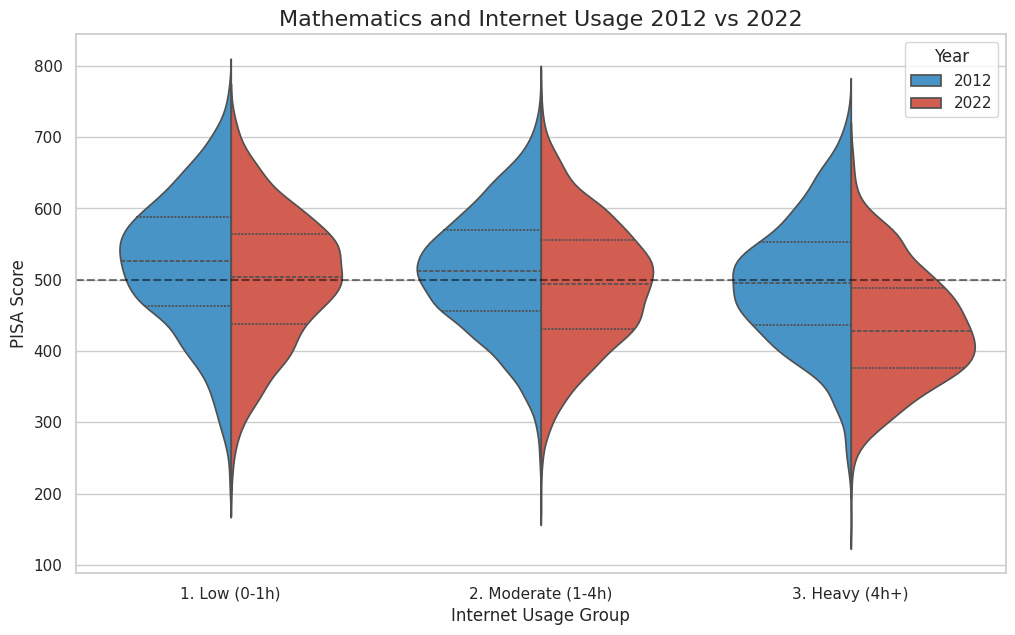

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transform Usage_Group to ordered categorical for better plotting
df_combined["Usage_Group"] = pd.Categorical(df_combined["Usage_Group"], 
    categories=["1. Low (0-1h)", "2. Moderate (1-4h)", "3. Heavy (4h+)"], 
    ordered=True)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")


ax = sns.violinplot(x="Usage_Group", y="Score", hue="Year", data=df_combined, 
                    split=True, inner="quart", palette={"2012": "#3498db", "2022": "#e74c3c"})

plt.title('Mathematics and Internet Usage 2012 vs 2022', fontsize=16)
plt.ylabel('PISA Score')
plt.xlabel('Internet Usage Group')

plt.axhline(500, color='black', linestyle='--', alpha=0.5)

plt.show()

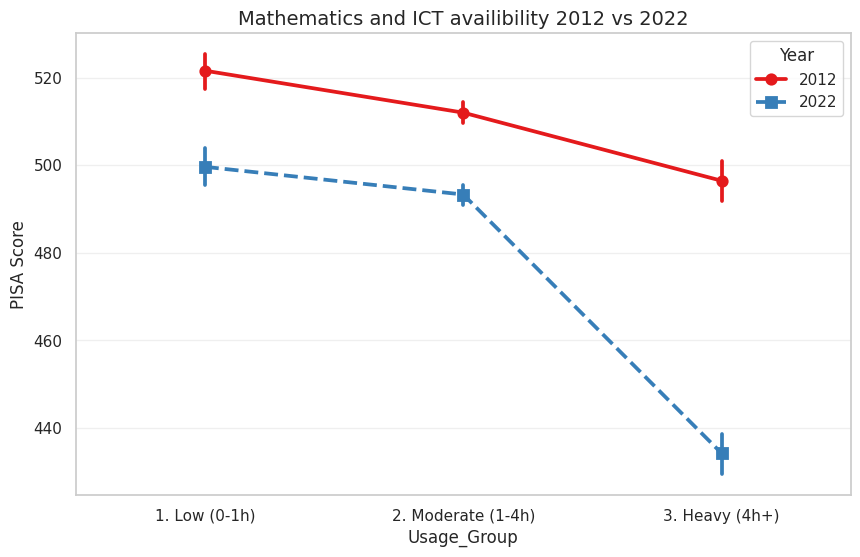

In [21]:
plt.figure(figsize=(10, 6))

sns.pointplot(x="Usage_Group", y="Score", hue="Year", data=df_combined, 
              markers=["o", "s"], linestyles=["-", "--"], palette="Set1")

plt.title('Mathematics and ICT availibility 2012 vs 2022', fontsize=14)
plt.ylabel('PISA Score')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

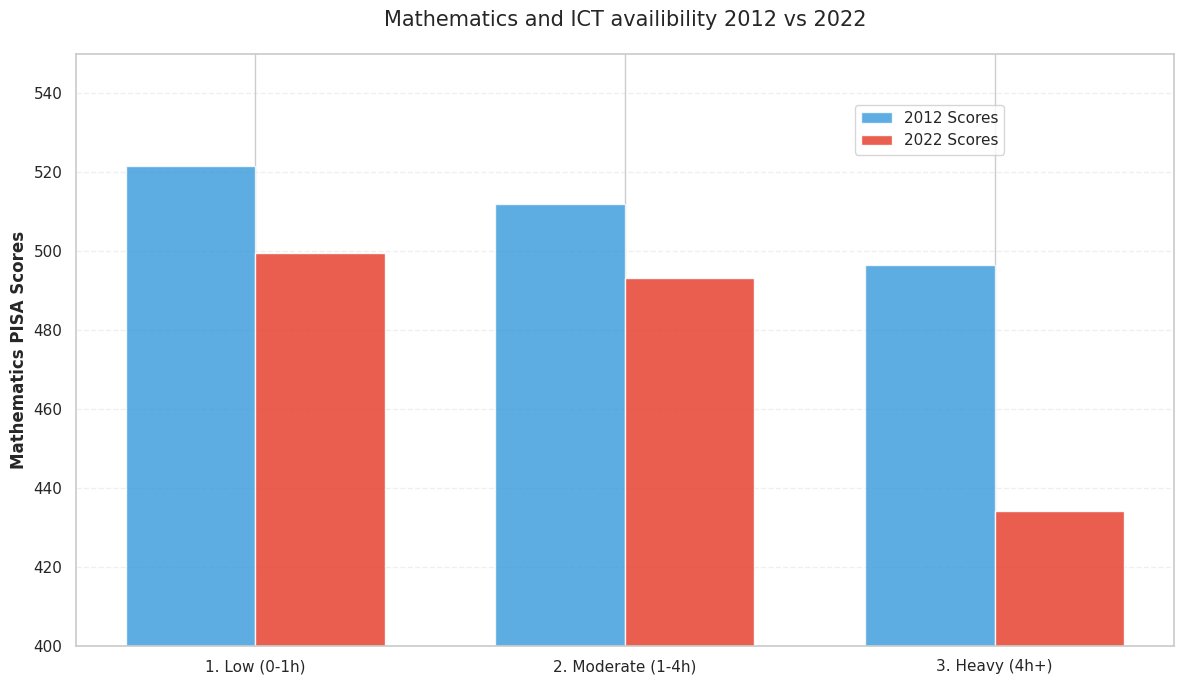

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA Mathematics ---
labels = ['1. Low (0-1h)', '2. Moderate (1-4h)', '3. Heavy (4h+)']
math_2012 = [521.6, 512.0, 496.5]
math_2022 = [499.6, 493.3, 434.2]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

# 1. Axis 1: Bars (Scores)
rects1 = ax1.bar(x - width/2, math_2012, width, label='2012 Scores', color='#3498db', alpha=0.8)
rects2 = ax1.bar(x + width/2, math_2022, width, label='2022 Scores', color='#e74c3c', alpha=0.9)

ax1.set_ylabel('Mathematics PISA Scores', fontsize=12, fontweight='bold')
ax1.set_ylim(400, 550)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Mathematics and ICT availibility 2012 vs 2022', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))

plt.tight_layout()
plt.show()